In [1]:
from pathlib import Path

In [2]:
from results.repetition import RepetitionResults
from results.results import Results
from results.topology_results import TopologyResults
from results.channel_results import ChannelResults

## Configuration


### Path Configuration


In [3]:
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20260204_17-30-33").resolve()


if not PATH_TO_RESULTS_PARENT_FOLDER.exists():
    raise FileNotFoundError(
        f"Results folder not found: {PATH_TO_RESULTS_PARENT_FOLDER}"
    )

In [4]:
# results = Results.from_folder(PATH_TO_RESULTS_PARENT_FOLDER)

In [5]:
rep = RepetitionResults.from_folder(
    PATH_TO_RESULTS_PARENT_FOLDER / "random_20N" / "lossy" / "12345"
)

In [6]:
len(rep.neighbor_df["timestamp"].unique())

45

In [7]:
rep.compute_hop_stretch()

,from,to,cg_path_length,tree_path_length,hop_stretch,timestamp
0,Node-1,Node-17,1.0,1.0,1.0,40.0
1,Node-1,Node-5,1.0,1.0,1.0,40.0
2,Node-1,Node-8,1.0,1.0,1.0,40.0
3,Node-1,Node-14,2.0,2.0,1.0,40.0
4,Node-1,Node-19,2.0,3.0,1.5,40.0
...,...,...,...,...,...,...
8545,Node-9,Node-16,1.0,1.0,1.0,1800.0
8546,Node-9,Node-13,2.0,2.0,1.0,1800.0
8547,Node-15,Node-16,1.0,5.0,5.0,1800.0
8548,Node-15,Node-13,2.0,6.0,3.0,1800.0


In [8]:
print(
    f"Hop stretch at timestamp 40: {rep.hop_stretch_df[rep.hop_stretch_df['timestamp'] == 40]['hop_stretch'].mean()}"
)
rep.hop_stretch_df[rep.hop_stretch_df["timestamp"] == 40]

Hop stretch at timestamp 40: 1.636904761904762


,from,to,cg_path_length,tree_path_length,hop_stretch,timestamp
0,Node-1,Node-17,1.0,1.0,1.0,40.0
1,Node-1,Node-5,1.0,1.0,1.0,40.0
2,Node-1,Node-8,1.0,1.0,1.0,40.0
3,Node-1,Node-14,2.0,2.0,1.0,40.0
4,Node-1,Node-19,2.0,3.0,1.5,40.0
...,...,...,...,...,...,...
185,Node-15,Node-18,NaN,NaN,NaN,40.0
186,Node-15,Node-20,NaN,NaN,NaN,40.0
187,Node-16,Node-18,NaN,NaN,NaN,40.0
188,Node-16,Node-20,NaN,NaN,NaN,40.0


In [9]:
rep.hop_stretch_df[rep.hop_stretch_df["timestamp"] == 200]

,from,to,cg_path_length,tree_path_length,hop_stretch,timestamp
760,Node-1,Node-17,1.0,1.0,1.000000,200.0
761,Node-1,Node-5,1.0,1.0,1.000000,200.0
762,Node-1,Node-6,1.0,1.0,1.000000,200.0
763,Node-1,Node-8,1.0,1.0,1.000000,200.0
764,Node-1,Node-2,6.0,7.0,1.166667,200.0
...,...,...,...,...,...,...
945,Node-14,Node-19,1.0,4.0,4.000000,200.0
946,Node-14,Node-10,3.0,4.0,1.333333,200.0
947,Node-13,Node-19,2.0,4.0,2.000000,200.0
948,Node-13,Node-10,4.0,4.0,1.000000,200.0


In [10]:
rep.hop_stretch_df[rep.hop_stretch_df["timestamp"] == 200]["hop_stretch"].mean()

np.float64(1.486165413533835)

## Test A Single timestamp

In [11]:
from metrics.hop_stretch import *
import matplotlib.pyplot as plt

In [12]:
g = build_connectivity_graph(rep, 200)

In [13]:
rep.neighbor_df.head()

,Unnamed: 0,timestamp,node_id,neighbor,type,nexthop,hops,etx,adv_metric,age,log_num
0,0,40.0,Node-1,Node-17,NODE_CHILD,0011,1,9.882133,8.931751,34.132754,1
1,1,40.0,Node-1,Node-5,NODE_CHILD,0005,1,8.164122,7.919825,6.206392,1
2,2,40.0,Node-1,Node-6,NODE_DESCENTANT,0011,2,9.387263,17.549853,inf,1
3,3,40.0,Node-1,Node-14,NODE_DESCENTANT,0011,2,9.378960,17.729036,inf,1
4,4,40.0,Node-1,Node-19,NODE_DESCENTANT,0011,41,0.000000,inf,inf,1


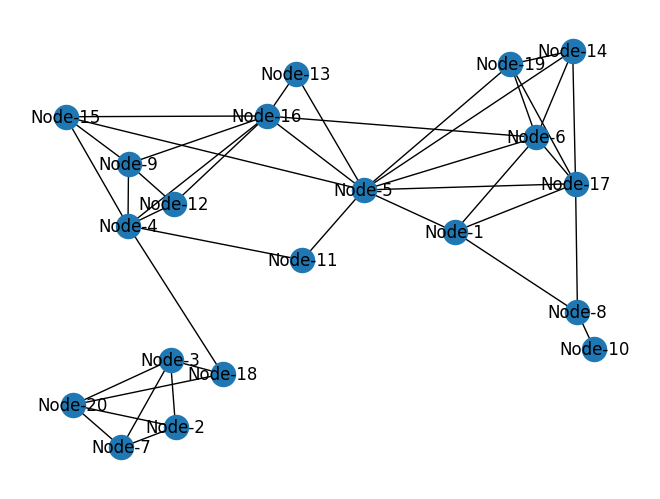

In [14]:
nx.draw(g, get_positions_nx(rep), with_labels=True)
plt.show()